<a href="https://colab.research.google.com/github/MaryamGondal/indian-food-calorie-estimation/blob/main/indianv11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Check GPU availability
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

# Make sure you're on GPU runtime
# Runtime > Change runtime type > T4 GPU

CUDA available: True
GPU: Tesla T4


In [2]:
# Install Ultralytics (YOLOv11 is part of ultralytics package)
!pip install ultralytics -q

# Verify installation
from ultralytics import YOLO
import ultralytics
ultralytics.checks()

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.5/112.6 GB disk)


In [24]:
import os

# Force unmount properly
os.system('fusermount -uz /content/drive 2>/dev/null || umount -f /content/drive 2>/dev/null')

# Remove the directory completely
os.system('rm -rf /content/drive')

# Wait a moment
import time
time.sleep(2)

# Now mount fresh
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [25]:
import os
print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'roll no.075.pdf', '075.pdf', 'https:  open.sp.txt', 'Look at this... 👀 (3)', 'Look at this... 👀 (2)', 'Look at this... 👀 (1)', 'New Doc 07-26-2022 21.25_4.jpg', 'Look at this... 👀', 'mpdf (1).pdf', 'mpdf.pdf', 'Snapchat-2016137743.jpg', 'Classroom', 'Pf assignment', 'Chap-01-Ex-1-3-Calculus-Prof-M-Tanveer (1).pdf', 'Untitled4-1.cpp', 'ttask2.cpp', 'ttask3.cpp', 'ttask5 (1).cpp', 'Untitled4 (1).cpp', 'salary task-1.cpp', 'salary task (1).cpp', 'salary task-2.cpp', 'salary task-3.cpp', 'salary task-4 (1).cpp', 'salarytax (1).cpp', 'tttask.cpp', "I am sharing 'roll no 0060-bscs-22  Name Maryam Gondal' with you.pdf", 'marks and avg (2).cpp', 'marks and avg (1).cpp', 'marks and avg.cpp', 'three integers (8).cpp', 'three integers (7).cpp', 'three integers (6).cpp', 'three integers (5).cpp', 'three integers (4).cpp', 'qoutient remainder task (3).cpp', 'qoutient remainder task (2).cpp', 'qoutient remainder task (1).cpp', 'three integers (3).cpp', 'three integers (2).cpp', 

In [26]:
import zipfile, os

ZIP_PATH = '/content/drive/MyDrive/indian_food_dataset.zip'
EXTRACT_TO = '/content/IndianFoodDataset'

os.makedirs(EXTRACT_TO, exist_ok=True)
print("Unzipping... please wait (2-3 minutes)...")

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_TO)

print("✅ Done! Contents:")
for item in os.listdir(EXTRACT_TO):
    print(" ", item)

Unzipping... please wait (2-3 minutes)...
✅ Done! Contents:
  test
  valid
  train
  README.dataset.txt
  data.yaml
  README.roboflow.txt


In [27]:
import yaml

DATASET_PATH = '/content/IndianFoodDataset'
yaml_path = f'{DATASET_PATH}/data.yaml'

with open(yaml_path, 'r') as f:
    content = f.read()

print(content)

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 81
names: ['adhirasam', 'aloo gobi', 'aloo matar', 'aloo methi', 'aloo shimla mirch', 'aloo tikki', 'anarsa', 'appe', 'ariselu', 'baati', 'bandar laddu', 'basundi', 'bhatura', 'bhindi masala', 'biryani', 'boondi', 'butter chicken', 'chak hao kheer', 'cham cham', 'chana masala', 'chapati', 'chicken rezala', 'chicken tikka', 'chicken tikka masala', 'chikki', 'churma', 'daal', 'daal puri', 'dal makhani', 'dal tadka', 'dharwad pedha', 'doodhpak', 'double ka meetha', 'dum aloo', 'gajar halwa', 'gavvalu', 'ghevar', 'gujia', 'gulab jamun', 'imarti', 'jalebi', 'kachori', 'kadai paneer', 'kadhi pakoda', 'kakinada khaja', 'kalakand', 'karela bharta', 'kheer', 'kofta', 'lassi', 'ledikeni', 'litti chokha', 'lyangcha', 'maach jhol', 'makki di roti sarso ka saag', 'malpua', 'misi roti', 'misti doi', 'modak', 'mysore pak', 'naan', 'navrattan korma', 'palak paneer', 'paneer butter masala', 'phirni', 'pithe', 'poha', 'poornalu', 'poo

In [28]:
DATASET_PATH = '/content/IndianFoodDataset'
yaml_path = f'{DATASET_PATH}/data.yaml'

# Fix the relative paths to absolute
with open(yaml_path, 'w') as f:
    f.write(f"""train: {DATASET_PATH}/train/images
val: {DATASET_PATH}/valid/images
test: {DATASET_PATH}/test/images

nc: 81
names: ['adhirasam', 'aloo gobi', 'aloo matar', 'aloo methi', 'aloo shimla mirch', 'aloo tikki', 'anarsa', 'appe', 'ariselu', 'baati', 'bandar laddu', 'basundi', 'bhatura', 'bhindi masala', 'biryani', 'boondi', 'butter chicken', 'chak hao kheer', 'cham cham', 'chana masala', 'chapati', 'chicken rezala', 'chicken tikka', 'chicken tikka masala', 'chikki', 'churma', 'daal', 'daal puri', 'dal makhani', 'dal tadka', 'dharwad pedha', 'doodhpak', 'double ka meetha', 'dum aloo', 'gajar halwa', 'gavvalu', 'ghevar', 'gujia', 'gulab jamun', 'imarti', 'jalebi', 'kachori', 'kadai paneer', 'kadhi pakoda', 'kakinada khaja', 'kalakand', 'karela bharta', 'kheer', 'kofta', 'lassi', 'ledikeni', 'litti chokha', 'lyangcha', 'maach jhol', 'makki di roti sarso ka saag', 'malpua', 'misi roti', 'misti doi', 'modak', 'mysore pak', 'naan', 'navrattan korma', 'palak paneer', 'paneer butter masala', 'phirni', 'pithe', 'poha', 'poornalu', 'pootharekulu', 'qubani ka meetha', 'rabri', 'ras malai', 'rasgulla', 'sandesh', 'shankarpali', 'sheera', 'shrikhand', 'soan papdi', 'sohan halwa', 'sutar feni', 'unni appam']
""")

print("✅ YAML fixed! Verifying...")
with open(yaml_path, 'r') as f:
    print(f.read())

✅ YAML fixed! Verifying...
train: /content/IndianFoodDataset/train/images
val: /content/IndianFoodDataset/valid/images
test: /content/IndianFoodDataset/test/images

nc: 81
names: ['adhirasam', 'aloo gobi', 'aloo matar', 'aloo methi', 'aloo shimla mirch', 'aloo tikki', 'anarsa', 'appe', 'ariselu', 'baati', 'bandar laddu', 'basundi', 'bhatura', 'bhindi masala', 'biryani', 'boondi', 'butter chicken', 'chak hao kheer', 'cham cham', 'chana masala', 'chapati', 'chicken rezala', 'chicken tikka', 'chicken tikka masala', 'chikki', 'churma', 'daal', 'daal puri', 'dal makhani', 'dal tadka', 'dharwad pedha', 'doodhpak', 'double ka meetha', 'dum aloo', 'gajar halwa', 'gavvalu', 'ghevar', 'gujia', 'gulab jamun', 'imarti', 'jalebi', 'kachori', 'kadai paneer', 'kadhi pakoda', 'kakinada khaja', 'kalakand', 'karela bharta', 'kheer', 'kofta', 'lassi', 'ledikeni', 'litti chokha', 'lyangcha', 'maach jhol', 'makki di roti sarso ka saag', 'malpua', 'misi roti', 'misti doi', 'modak', 'mysore pak', 'naan', 'na

In [29]:
import os
from ultralytics import YOLO

# Quick verify
for split in ['train', 'valid', 'test']:
    imgs = len(os.listdir(f'{DATASET_PATH}/{split}/images'))
    lbls = len(os.listdir(f'{DATASET_PATH}/{split}/labels'))
    print(f"{split:6} → Images: {imgs:5} | Labels: {lbls:5} | {'✅' if imgs == lbls else '⚠️ MISMATCH'}")

print("\n🚀 Starting training...")

model = YOLO('yolo11s.pt')

results = model.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,
    project='/content/drive/MyDrive/FoodDetection_Runs',
    name='indian_food_v1',
    patience=10,
    pretrained=True,
    device=0
)

train  → Images:  3111 | Labels:  3111 | ✅
valid  → Images:   362 | Labels:   362 | ✅
test   → Images:   381 | Labels:   381 | ✅

🚀 Starting training...
Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/IndianFoodDataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentu

Saving Aloo-Gobi-5.jpg to Aloo-Gobi-5.jpg

image 1/1 /content/Aloo-Gobi-5.jpg: 640x640 1 aloo gobi, 15.7ms
Speed: 4.8ms preprocess, 15.7ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)


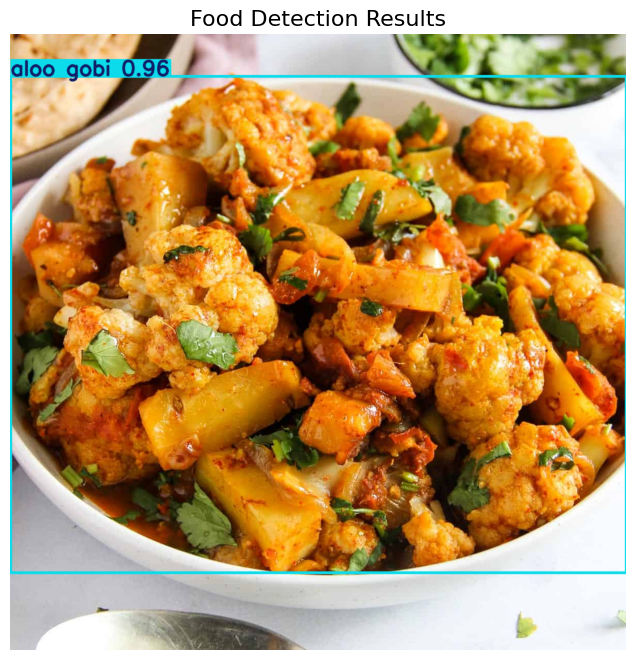


🍽️  DETECTED ITEMS:
✅  aloo gobi                            Confidence: 95.7%


In [33]:
# TESTINGGGG


from google.colab import files
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from PIL import Image

# Load your trained model
MODEL_PATH = '/content/drive/MyDrive/FoodDetection_Runs/indian_food_v1/weights/best.pt'
model = YOLO(MODEL_PATH)

# Upload any food image from your computer
uploaded = files.upload()  # file picker appears
image_path = list(uploaded.keys())[0]

# Run prediction
results = model.predict(
    source=image_path,
    conf=0.40,        # optimal threshold we found
    save=False
)

# Display result
for r in results:
    img = r.plot()   # draws boxes on image
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title('Food Detection Results', fontsize=16)
    plt.show()

    # Print what was detected
    print("\n🍽️  DETECTED ITEMS:")
    print("="*40)
    if len(r.boxes) == 0:
        print("❌ Nothing detected — try a clearer image or lower confidence")
    for box in r.boxes:
        class_id = int(box.cls[0])
        food_name = model.names[class_id]
        confidence = float(box.conf[0]) * 100
        print(f"✅  {food_name:<35}  Confidence: {confidence:.1f}%")

CALORIEE ESTIMATION PART

In [34]:
# ============================================
# PHASE 2 — CALORIE ESTIMATION
# ============================================

# Calorie map: calories per 100g for all 81 classes
CALORIE_MAP = {
    'adhirasam': 347,
    'aloo gobi': 98,
    'aloo matar': 112,
    'aloo methi': 105,
    'aloo shimla mirch': 95,
    'aloo tikki': 210,
    'anarsa': 380,
    'appe': 145,
    'ariselu': 365,
    'baati': 298,
    'bandar laddu': 410,
    'basundi': 186,
    'bhatura': 315,
    'bhindi masala': 87,
    'biryani': 198,
    'boondi': 425,
    'butter chicken': 164,
    'chak hao kheer': 172,
    'cham cham': 298,
    'chana masala': 164,
    'chapati': 297,
    'chicken rezala': 152,
    'chicken tikka': 172,
    'chicken tikka masala': 158,
    'chikki': 478,
    'churma': 372,
    'daal': 116,
    'daal puri': 285,
    'dal makhani': 152,
    'dal tadka': 124,
    'dharwad pedha': 385,
    'doodhpak': 178,
    'double ka meetha': 295,
    'dum aloo': 145,
    'gajar halwa': 192,
    'gavvalu': 358,
    'ghevar': 396,
    'gujia': 372,
    'gulab jamun': 352,
    'imarti': 345,
    'jalebi': 358,
    'kachori': 325,
    'kadai paneer': 195,
    'kadhi pakoda': 142,
    'kakinada khaja': 368,
    'kalakand': 358,
    'karela bharta': 72,
    'kheer': 178,
    'kofta': 225,
    'lassi': 98,
    'ledikeni': 315,
    'litti chokha': 268,
    'lyangcha': 298,
    'maach jhol': 128,
    'makki di roti sarso ka saag': 142,
    'malpua': 298,
    'misi roti': 278,
    'misti doi': 145,
    'modak': 185,
    'mysore pak': 452,
    'naan': 310,
    'navrattan korma': 185,
    'palak paneer': 178,
    'paneer butter masala': 198,
    'phirni': 165,
    'pithe': 198,
    'poha': 158,
    'poornalu': 285,
    'pootharekulu': 375,
    'qubani ka meetha': 195,
    'rabri': 215,
    'ras malai': 188,
    'rasgulla': 186,
    'sandesh': 298,
    'shankarpali': 445,
    'sheera': 285,
    'shrikhand': 245,
    'soan papdi': 452,
    'sohan halwa': 425,
    'sutar feni': 398,
    'unni appam': 198,
}

# Standard serving sizes in grams for each class
SERVING_SIZE_MAP = {
    'adhirasam': 60,        'aloo gobi': 150,
    'aloo matar': 150,      'aloo methi': 150,
    'aloo shimla mirch': 150, 'aloo tikki': 80,
    'anarsa': 40,           'appe': 120,
    'ariselu': 50,          'baati': 120,
    'bandar laddu': 50,     'basundi': 150,
    'bhatura': 80,          'bhindi masala': 150,
    'biryani': 250,         'boondi': 30,
    'butter chicken': 200,  'chak hao kheer': 150,
    'cham cham': 80,        'chana masala': 150,
    'chapati': 40,          'chicken rezala': 200,
    'chicken tikka': 150,   'chicken tikka masala': 200,
    'chikki': 30,           'churma': 100,
    'daal': 200,            'daal puri': 80,
    'dal makhani': 200,     'dal tadka': 200,
    'dharwad pedha': 40,    'doodhpak': 150,
    'double ka meetha': 120,'dum aloo': 150,
    'gajar halwa': 100,     'gavvalu': 50,
    'ghevar': 80,           'gujia': 60,
    'gulab jamun': 50,      'imarti': 80,
    'jalebi': 60,           'kachori': 80,
    'kadai paneer': 180,    'kadhi pakoda': 200,
    'kakinada khaja': 60,   'kalakand': 80,
    'karela bharta': 150,   'kheer': 150,
    'kofta': 150,           'lassi': 250,
    'ledikeni': 60,         'litti chokha': 200,
    'lyangcha': 60,         'maach jhol': 200,
    'makki di roti sarso ka saag': 200, 'malpua': 80,
    'misi roti': 50,        'misti doi': 100,
    'modak': 50,            'mysore pak': 50,
    'naan': 90,             'navrattan korma': 180,
    'palak paneer': 180,    'paneer butter masala': 180,
    'phirni': 150,          'pithe': 80,
    'poha': 150,            'poornalu': 60,
    'pootharekulu': 30,     'qubani ka meetha': 100,
    'rabri': 100,           'ras malai': 100,
    'rasgulla': 50,         'sandesh': 50,
    'shankarpali': 30,      'sheera': 100,
    'shrikhand': 100,       'soan papdi': 30,
    'sohan halwa': 50,      'sutar feni': 30,
    'unni appam': 50,
}

print(f"✅ Calorie map loaded — {len(CALORIE_MAP)} food classes")
print(f"✅ Serving size map loaded — {len(SERVING_SIZE_MAP)} food classes")

✅ Calorie map loaded — 81 food classes
✅ Serving size map loaded — 81 food classes


In [35]:
!pip install transformers accelerate -q

from transformers import pipeline
import torch

print("Loading Depth Anything V2 model...")

depth_estimator = pipeline(
    task="depth-estimation",
    model="depth-anything/Depth-Anything-V2-Small-hf",
    device=0 if torch.cuda.is_available() else -1
)

print("✅ Depth model loaded!")

Loading Depth Anything V2 model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/99.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

The image processor of type `DPTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


✅ Depth model loaded!


In [36]:
import numpy as np
import cv2
from PIL import Image
import math

def get_depth_map(image_path):
    image = Image.open(image_path).convert('RGB')
    result = depth_estimator(image)
    depth_map = np.array(result['depth'])
    # Normalize to 0-1
    depth_map = (depth_map - depth_map.min()) / (depth_map.max() - depth_map.min())
    return depth_map

def estimate_portion(bbox, depth_map, image_shape, food_name):
    img_h, img_w = image_shape[:2]
    x1, y1, x2, y2 = [int(b) for b in bbox]

    # Resize depth map to image size
    depth_resized = cv2.resize(depth_map, (img_w, img_h))

    # Get average depth inside bounding box
    food_region = depth_resized[y1:y2, x1:x2]
    avg_depth = float(np.mean(food_region))

    # Pixel dimensions of bounding box
    bbox_w_px = x2 - x1
    bbox_h_px = y2 - y1

    # Assume plate = 80% of image width, standard plate = 25cm
    pixels_per_cm = (img_w * 0.8) / 25.0

    # Convert bbox to cm
    bbox_w_cm = bbox_w_px / pixels_per_cm
    bbox_h_cm = bbox_h_px / pixels_per_cm

    # Map depth (0-1) to food height (0.5cm to 8cm)
    food_height_cm = 0.5 + (avg_depth * 7.5)
    food_height_cm = max(0.5, min(8.0, food_height_cm))

    # Volume as elliptical cylinder (cm³)
    volume_cm3 = math.pi * (bbox_w_cm / 2) * (bbox_h_cm / 2) * food_height_cm

    # Fixed density 0.85 g/cm³ (average for Indian food)
    weight_grams = volume_cm3 * 0.85

    # Clamp to realistic range
    weight_grams = max(20, min(600, weight_grams))

    return round(weight_grams, 1), round(avg_depth, 3)

print("✅ Helper functions ready!")

✅ Helper functions ready!


In [37]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.patches as patches

MODEL_PATH = '/content/drive/MyDrive/FoodDetection_Runs/indian_food_v1/weights/best.pt'
model = YOLO(MODEL_PATH)

def analyze_image(image_path):
    # Step 1 — Get depth map
    print("📐 Running depth estimation...")
    depth_map = get_depth_map(image_path)

    # Step 2 — Detect food
    print("🔍 Detecting food items...")
    results = model.predict(source=image_path, conf=0.40, verbose=False)

    image_cv = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image_cv, cv2.COLOR_BGR2RGB)

    total_calories = 0
    detections = []

    for r in results:
        for box in r.boxes:
            food_name = model.names[int(box.cls[0])]
            confidence = float(box.conf[0]) * 100
            bbox = box.xyxy[0].tolist()

            # Step 3 — Estimate portion using depth
            portion_g, depth_val = estimate_portion(
                bbox, depth_map, image_cv.shape, food_name
            )

            # Step 4 — Calculate calories
            cal_per_100g = CALORIE_MAP.get(food_name, 200)
            calories = round((portion_g / 100) * cal_per_100g, 1)
            total_calories += calories

            detections.append({
                'food': food_name,
                'confidence': round(confidence, 1),
                'portion_g': portion_g,
                'calories': calories,
                'bbox': bbox
            })

    # Step 5 — Display results
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Left — detection with boxes
    ax1 = axes[0]
    ax1.imshow(image_rgb)
    for det in detections:
        x1, y1, x2, y2 = det['bbox']
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                   linewidth=2, edgecolor='lime', facecolor='none')
        ax1.add_patch(rect)
        ax1.text(x1, y1 - 8,
                 f"{det['food']} | {det['calories']} kcal",
                 color='lime', fontsize=9, fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.6))
    ax1.set_title('Food Detection', fontsize=14, fontweight='bold')
    ax1.axis('off')

    # Right — depth map
    ax2 = axes[1]
    ax2.imshow(depth_map, cmap='plasma')
    ax2.set_title('Depth Map (brighter = closer to camera)', fontsize=14, fontweight='bold')
    ax2.axis('off')

    plt.suptitle(f'🔥 Total Estimated Calories: {round(total_calories, 1)} kcal',
                 fontsize=16, fontweight='bold', color='darkred')
    plt.tight_layout()
    plt.show()

    # Print text summary
    print("\n" + "="*55)
    print("🍽️   CALORIE ESTIMATION RESULTS")
    print("="*55)
    if not detections:
        print("❌ No food detected. Try a clearer image.")
    for det in detections:
        print(f"✅  {det['food']:<32} {det['portion_g']:>6}g   →   {det['calories']:>7} kcal   (conf: {det['confidence']}%)")
    print("="*55)
    print(f"🔥  TOTAL CALORIES: {round(total_calories, 1)} kcal")
    print("="*55)

print("✅ Pipeline ready!")

✅ Pipeline ready!


Upload any Indian food image...


Saving pexels-kunal-lakhotia-781256899-29173114.jpg to pexels-kunal-lakhotia-781256899-29173114.jpg
📐 Running depth estimation...
🔍 Detecting food items...


/tmp/ipykernel_23516/4294936159.py:73: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


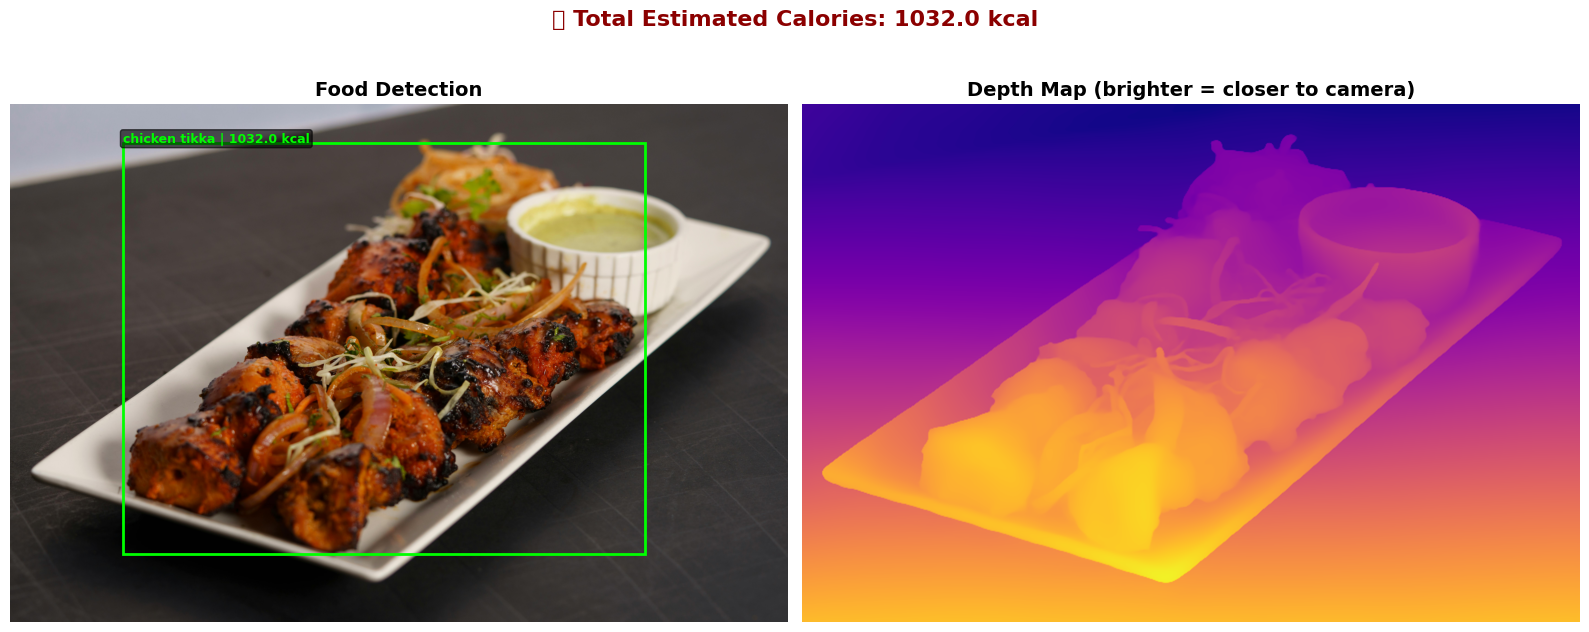


🍽️   CALORIE ESTIMATION RESULTS
✅  chicken tikka                       600g   →    1032.0 kcal   (conf: 77.4%)
🔥  TOTAL CALORIES: 1032.0 kcal


In [41]:
from google.colab import files

print("Upload any Indian food image...")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

analyze_image(image_path)